# Dask Performance: Lazy Evaluation and Speedup

This notebook covers two key Dask concepts: **lazy evaluation** (task graphs, when to call `.compute()`) and **parallel speedup** (benchmarking Pandas vs Dask on a 2D histogram problem).

In [1]:
import pathlib
import time
import dask.dataframe as dd
import dask.array as da
from dask.distributed import Client
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

print(f"Available RAM: {psutil.virtual_memory().available / (1024 ** 3):.1f} GB")

Available RAM: 8.0 GB


## Part 1: Lazy Evaluation and Task Graphs

Dask operations build a computation graph instead of executing immediately. This enables optimization before execution.

In [2]:
# Load the weather HDF5 we created in the previous notebook
data_path = pathlib.Path("meteo") / "meteo_dask.h5"
assert data_path.exists(), f"Run notebook 02 first to create {data_path}"
df = dd.read_hdf(data_path, key="df")

In [3]:
# .head() is eager — it triggers computation of the first few rows
df.head()

,Date,Time,TempOut,TempHi,TempLow,HumOut,DewPt,WindSpeed,WindDir,WindRun,...,CoolDD,TempIn,HumIn,DewPtIn,HeatIn,ET,WindSamp,WindTx,ISSRecept,ArcInt
0,24-12-29,0:30,0.4,0.4,0.3,98,0.1,0.0,NE,0.0,...,0.0,18.4,30,0.5,16.4,0.0,699.0,1.0,100.0,30.0
1,24-12-29,1:00,0.1,0.3,-0.1,98,-0.2,0.0,NE,0.0,...,0.0,18.4,30,0.5,16.4,0.0,699.0,1.0,100.0,30.0
2,24-12-29,1:30,-0.2,-0.1,-0.3,98,-0.5,0.0,NE,0.0,...,0.0,18.3,30,0.4,16.4,0.0,699.0,1.0,100.0,30.0
3,24-12-29,2:00,-0.3,-0.3,-0.4,98,-0.6,0.0,NE,0.0,...,0.0,18.3,30,0.4,16.3,0.0,700.0,1.0,100.0,30.0
4,24-12-29,2:30,-0.5,-0.4,-0.6,98,-0.8,0.0,NE,0.0,...,0.0,18.3,30,0.4,16.3,0.0,701.0,1.0,100.0,30.0


In [4]:
# This is LAZY — returns a Dask Scalar, not a number
lazy_result = df[df.HumOut > 0].TempOut.mean()
lazy_result

<dask_expr.expr.Scalar: expr=((Filter(frame=ArrowStringConversion(frame=FromMapProjectable(09cc81f)), predicate=ArrowStringConversion(frame=FromMapProjectable(09cc81f))['HumOut'] > 0))['TempOut']).mean(), dtype=float64>

In [5]:
# .compute() triggers execution of the entire graph
lazy_result.compute()

np.float64(11.131679235796883)

### Task Graph Visualization

Uncomment to see the computation graph. This shows how Dask breaks the operation into parallel tasks across partitions.

In [6]:
# df[df.HumOut > 0].TempOut.mean().visualize(engine="graphviz")

### GroupBy: Distributed Aggregation

GroupBy requires data shuffling between partitions — a more complex operation than simple filtering.

In [7]:
%%time
df.TempOut.groupby(df.HumOut).mean().compute()

CPU times: user 58.2 ms, sys: 4.01 ms, total: 62.2 ms
Wall time: 61.5 ms


HumOut
-1            NaN
 23     20.900000
 24     20.550000
 25     20.233333
 26     19.750000
          ...    
 96      5.943719
 97      6.644605
 98      6.782613
 99      5.282012
 100    11.297674
Name: TempOut, Length: 78, dtype: float64

## Part 2: Pandas vs Dask Benchmark

We compare single-threaded Pandas with distributed Dask on a CPU-intensive task: 2D histogram of 100M simulated physics measurements.

In [8]:
n_samples = 100_000_000
distance_mean_m = 100
distance_sigma_m = 10
time_mean_s = 10
time_sigma_s = 0.1

cmap = mcolors.LinearSegmentedColormap.from_list("custom", [(0,0,0,0), (0,1,0,1), (1,0,0,1)], N=128)

### Pandas Approach (single-threaded)

In [9]:
%%time
df_pandas = pd.DataFrame({
    "distance_m": np.random.normal(loc=distance_mean_m, scale=distance_sigma_m, size=n_samples),
    "time_s": np.random.normal(loc=time_mean_s, scale=time_sigma_s, size=n_samples),
})

CPU times: user 2.23 s, sys: 1.84 s, total: 4.08 s
Wall time: 4.07 s


In [10]:
%%time
hist_pandas, xedges, yedges = np.histogram2d(df_pandas.distance_m, df_pandas.time_s, bins=500)

CPU times: user 7.85 s, sys: 2.05 s, total: 9.9 s
Wall time: 9.9 s


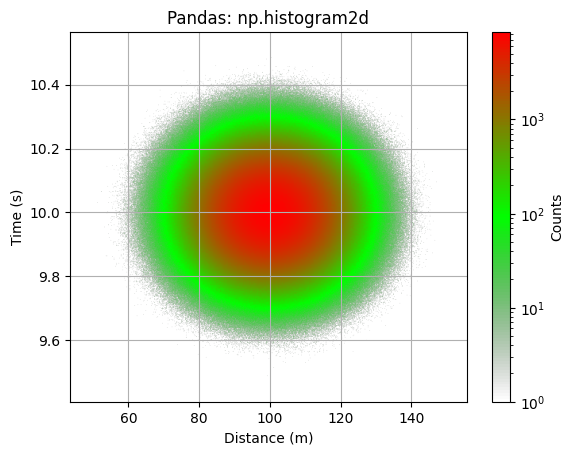

In [11]:
norm = mcolors.LogNorm(vmin=1, vmax=hist_pandas.max())
plt.imshow(hist_pandas.T, origin="lower", aspect="auto",
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           cmap=cmap, norm=norm)
plt.xlabel("Distance (m)")
plt.ylabel("Time (s)")
plt.title("Pandas: np.histogram2d")
plt.colorbar(label="Counts")
plt.grid()

### Dask Approach (distributed)

Start a local Dask cluster. The dashboard (default port 8787) shows live task execution and memory usage.

In [12]:
# Use your assigned port from 00_setup (change if needed)
DASHBOARD_PORT = 8788  # adjust to your participant number
client = Client(dashboard_address=f":{DASHBOARD_PORT}")
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8788/status,
Dashboard: http://127.0.0.1:8788/status,Workers: 7
Total threads: 14,Total memory: 30.84 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38255,Workers: 0
Dashboard: http://127.0.0.1:8788/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39139,Total threads: 2
Dashboard: http://127.0.0.1:39307/status,Memory: 4.41 GiB
Nanny: tcp://127.0.0.1:36877,


In [13]:
# Create lazy distributed arrays
distance_dask = da.random.normal(loc=distance_mean_m, scale=distance_sigma_m, size=n_samples, chunks="auto")
time_dask = da.random.normal(loc=time_mean_s, scale=time_sigma_s, size=n_samples, chunks="auto")

In [14]:
# Pre-compute range for consistent binning across workers
d_min, d_max, t_min, t_max = da.compute(
    distance_dask.min(), distance_dask.max(),
    time_dask.min(), time_dask.max()
)

In [15]:
%%time
hist_dask, xedges_d, yedges_d = da.histogram2d(
    distance_dask, time_dask, bins=(500, 500),
    range=[[d_min, d_max], [t_min, t_max]]
)

CPU times: user 1.68 ms, sys: 214 μs, total: 1.9 ms
Wall time: 1.91 ms


In [16]:
%%time
hist_dask, xedges_d, yedges_d = da.compute(hist_dask, xedges_d, yedges_d)

CPU times: user 196 ms, sys: 47.4 ms, total: 244 ms
Wall time: 3.27 s


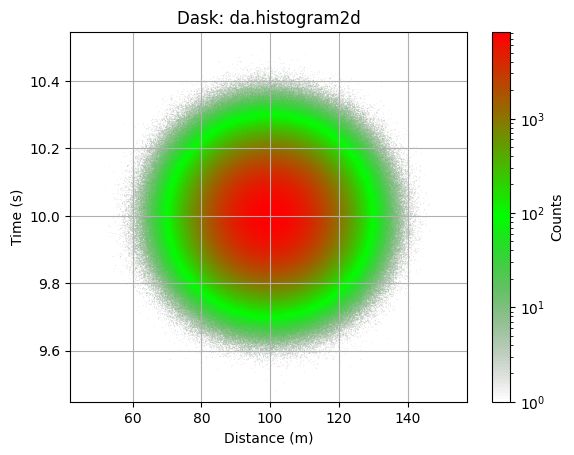

In [17]:
norm = mcolors.LogNorm(vmin=1, vmax=hist_dask.max())
plt.imshow(hist_dask.T, origin="lower", aspect="auto",
           extent=[xedges_d[0], xedges_d[-1], yedges_d[0], yedges_d[-1]],
           cmap=cmap, norm=norm)
plt.xlabel("Distance (m)")
plt.ylabel("Time (s)")
plt.title("Dask: da.histogram2d")
plt.colorbar(label="Counts")
plt.grid()

## Exercise: Find the Crossover Point

At what dataset size does Dask become faster than Pandas for the 2D histogram? Test multiple sizes and plot the results.

In [18]:
# Exercise: benchmark Pandas vs Dask at different dataset sizes

sample_sizes = [10_000, 100_000, 1_000_000, 10_000_000, 100_000_000]
pandas_times = []
dask_times = []

for n in sample_sizes:
    # YOUR CODE HERE: time the Pandas approach (np.histogram2d)
    pass

    # YOUR CODE HERE: time the Dask approach (da.histogram2d + .compute())
    pass

# YOUR CODE HERE: plot sample_sizes vs times for both
# plt.loglog(sample_sizes, pandas_times, "o-", label="Pandas")
# plt.loglog(sample_sizes, dask_times, "s-", label="Dask")
# plt.xlabel("Dataset size")
# plt.ylabel("Wall time (s)")
# plt.legend()
# plt.grid(True)

In [19]:
client.close()